In [1]:
import pandas as pd
import os

files = {
    "Electricity": [
        "grid_search_electricity_results_[True, False]_True_[1]_[1]_[24]_[1, 2, 6, 12, 24]_[True, False]_[True, False]_[4].csv",
    ],
    "Traffic": [
        "grid_search_traffic_results_[True, False]_True_[1]_[1]_[24]_[1, 2, 6, 12, 24]_[True, False]_[True, False]_[4].csv",
    ],
    "PeMSD7": [
        "grid_search_pems_results_[True, False]_True_[1]_[1]_[9]_[1, 2, 3, 5, 9]_[True, False]_[True, False]_[4].csv",
    ],
    "Exchange-Rate": [
        "grid_search_exchange_rate_results_[True, False]_True_[1]_[1]_[24]_[1, 2, 6, 12, 24]_[True, False]_[True, False]_[4].csv",
    ],
}

base_path = "../results/local_daikon/0-base/"

dfs = []
for dataset_name, file_list in files.items():
    for f in file_list:
        full_path = os.path.join(base_path, f)
        try:
            if os.path.exists(full_path):
                df = pd.read_csv(full_path)
                df["dataset"] = dataset_name  # Tag the rows
                dfs.append(df)
            else:
                print(f"Warning: File not found {full_path}")
        except Exception as e:
            print(f"Error reading {full_path}: {e}")

all_df = pd.concat(dfs, ignore_index=True)

In [2]:
all_df

,include_covariates,include_itself,include_motif_information,k_motifs,motif_length,no_points_after_motif,do_normalization,include_similarity,EXCL_ZONE_DENOM,RMSE,WAPE,MAE,MAPE,Time_Processing,Time_Overall,dataset
0,True,True,1,1,24,1,True,True,4,139.857000,0.094442,52.898056,inf,51.067061,351.555020,Electricity
1,True,True,1,1,24,1,True,False,4,139.504090,0.093986,52.642290,inf,49.346821,342.529759,Electricity
2,True,True,1,1,24,1,False,True,4,141.308350,0.095551,53.519142,inf,46.756178,345.161769,Electricity
3,True,True,1,1,24,1,False,False,4,138.730010,0.093408,52.318770,inf,47.052109,340.629526,Electricity
4,True,True,1,1,24,2,True,True,4,136.314560,0.094533,52.948734,inf,49.259624,354.641088,Electricity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,False,True,1,1,24,12,False,False,4,0.018711,0.015298,0.011435,0.047507,0.793745,7.275468,Exchange-Rate
156,False,True,1,1,24,24,True,True,4,0.019591,0.015719,0.011750,0.047319,0.963542,8.739136,Exchange-Rate
157,False,True,1,1,24,24,True,False,4,0.019617,0.015723,0.011752,0.047167,0.932240,8.566791,Exchange-Rate
158,False,True,1,1,24,24,False,True,4,0.018677,0.015283,0.011424,0.047333,0.912311,8.508493,Exchange-Rate


In [3]:
# Define Matching Columns
# These columns identify a unique model configuration (excluding the normalization setting)
group_cols = [
    "dataset",
    "include_covariates",
    "include_motif_information",
    "include_similarity",
    "k_motifs",
    "no_points_after_motif",
]

metrics = ["RMSE", "WAPE", "MAE"]

# We create a table where one column is the 'True' (Normalized) score and one is 'False' (Unnormalized)
pivot_df = all_df.pivot_table(
    index=group_cols, columns="do_normalization", values=metrics
)
print(pivot_df.shape)

(80, 6)


In [4]:
pivot_df

MAE  \
do_normalization                                                                                                False   
dataset     include_covariates include_motif_information include_similarity k_motifs no_points_after_motif              
Electricity False              1                         False              1        1                      58.526413   
                                                                                     2                      58.552547   
                                                                                     6                      58.680813   
                                                                                     12                     57.060688   
                                                                                     24                     55.861893   
...                                                                                                               ...   
Traffic     True               1                         True               1        1                       0.006267   
                                                                                     2                       0.006325   
                                                                                     6                       0.006127   
                                                                                     12                      0.005392   
                                                                                     24                      0.003441   

                                                                                                                       \
do_normalization                                                                                                True    
dataset     include_covariates include_motif_information include_similarity k_motifs no_points_after_motif              
Electricity False              1                         False              1        1                      58.193530   
                                                                                     2                      58.712130   
                                                                                     6                      59.141224   
                                                                                     12                     58.689720   
                                                                                     24                     56.543186   
...                                                                                                               ...   
Traffic     True               1                         True               1        1                       0.006210   
                                                                                     2                       0.006205   
                                                                                     6                       0.006480   
                                                                                     12                      0.006523   
                                                                                     24                      0.005385   

                                                                                                                  RMSE  \
do_normalization                                                                                                 False   
dataset     include_covariates include_motif_information include_similarity k_motifs no_points_after_motif               
Electricity False              1                         False              1        1                      140.038530   
                                                                                     2                      140.940920   
                                                                                     6                      146.26

In [5]:
# Calculate Percentage Increase in Error
# Formula: ((Normalized - Unnormalized) / Unnormalized) * 100
# Positive value = Normalized has higher error (Unnormalized is better)
results = pd.DataFrame(index=pivot_df.index)

for m in metrics:
    # (Value_with_Norm - Value_without_Norm) / Value_without_Norm
    diff = pivot_df[(m, True)] - pivot_df[(m, False)]
    pct_diff = (diff / pivot_df[(m, False)]) * 100
    results[f"{m}_pct_increase"] = pct_diff

summary = results.groupby("dataset")[[f"{m}_pct_increase" for m in metrics]].mean()

print("-" * 60)
print("Impact of Normalization (Percentage Increase in Error)")
print("Positive values mean Normalization made the model WORSE.")
print("-" * 60)
print(summary.round(2))
print("-" * 60)

------------------------------------------------------------
Impact of Normalization (Percentage Increase in Error)
Positive values mean Normalization made the model WORSE.
------------------------------------------------------------
               RMSE_pct_increase  WAPE_pct_increase  MAE_pct_increase
dataset                                                              
Electricity                -0.20               0.47              0.47
Exchange-Rate               4.60               2.66              2.66
PeMSD7                      0.26               0.29              0.29
Traffic                    15.94              16.00             16.00
------------------------------------------------------------


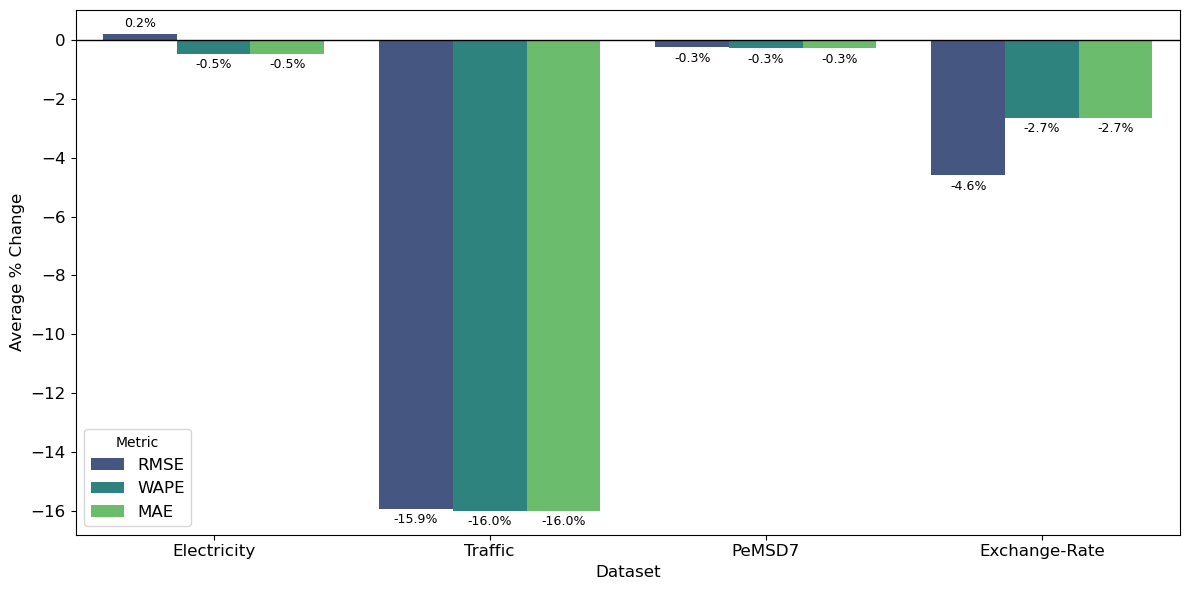

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = results.copy().reset_index()

rename_map = {f"{m}_pct_increase": m for m in metrics}
plot_df = plot_df.rename(columns=rename_map)

avg_imp = plot_df.groupby("dataset")[metrics].mean().reset_index()

melted_imp = avg_imp.melt(
    id_vars="dataset", value_vars=metrics, var_name="Metric", value_name="pct_increase"
)

melted_imp["pct_increase"] = -melted_imp["pct_increase"]

# Plot
plt.figure(figsize=(12, 6))
dataset_order = ["Electricity", "Traffic", "PeMSD7", "Exchange-Rate"]
sns.barplot(
    data=melted_imp,
    x="dataset",
    y="pct_increase",
    hue="Metric",
    palette="viridis",
    order=dataset_order,
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Average % Change", fontsize="large")
plt.xlabel("Dataset", fontsize="large")
# plt.title('Impact of Normalization on Error Metrics', fontsize=14, fontweight='bold')
plt.legend(title="Metric", fontsize="large")
plt.tick_params(axis="both", labelsize="large")

# Add values on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("../figures/original_vs_normalize.pdf")
plt.show()

In [7]:
import datetime

print(f"This notebook was last run end-to-end on: {datetime.datetime.now()}\n")

This notebook was last run end-to-end on: 2026-06-19 01:58:34.415411

